In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [ ]:
train_raw = pd.read_parquet('datasets/block1_train.parquet', engine='fastparquet')
test2_raw = pd.read_parquet('datasets/block2_test.parquet', engine='fastparquet')
test3_raw = pd.read_parquet('datasets/block3_test.parquet', engine='fastparquet')

insurer_cols = [c for c in train_raw.columns if c.endswith('_price')]
insurers = [c.replace('_price', '') for c in insurer_cols]

print(f"Train shape: {train_raw.shape}")
print(f"Test2 shape: {test2_raw.shape}")
print(f"Test3 shape: {test3_raw.shape}")
print(f"Insurers: {insurers}")

Train shape: (541292, 155)
Test2 shape: (164092, 144)
Test3 shape: (142216, 144)
Insurers: ['Insurer_A', 'Insurer_B', 'Insurer_C', 'Insurer_D', 'Insurer_E', 'Insurer_F', 'Insurer_G', 'Insurer_H', 'Insurer_I', 'Insurer_J', 'Insurer_K']


In [9]:
print(train_raw.columns.tolist())

['quote_id', 'vehicle_ownership_duration', 'vehicle_number_plate', 'coverage', 'claim_free_years', 'payment_frequency', 'contractor_birthdate', 'is_driver_owner', 'usage', 'second_driver_birthdate', 'second_driver_claim_free_years', 'vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_number_of_wheels', 'vehicle_primary_color', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age', 'vehicle_first_registration_date', 'vehicle_country_first_registration_date', 'vehicle_last_registration_date', 'vehicle_years_since_country_first_registration', 'vehicle_inspection_report_date', 'vehicle_inspection_expiry_date', 'vehicle_inspection_number_of_def

In [10]:
train_raw['claim_free_years'] = pd.to_numeric(train_raw['claim_free_years'], errors='coerce')
train_raw['vehicle_value_new'] = pd.to_numeric(train_raw['vehicle_value_new'], errors='coerce')
train_raw['contractor_birthdate'] = pd.to_datetime(train_raw['contractor_birthdate'], errors='coerce')
train_raw['driver_age'] = (pd.Timestamp('2024-01-01') - train_raw['contractor_birthdate']).dt.days / 365.25

insurer_cols = [c for c in train_raw.columns if c.endswith('_price')]
insurers = [c.replace('_price', '') for c in insurer_cols]

sns.set_theme(style='whitegrid')
print("Ready.")

Ready.


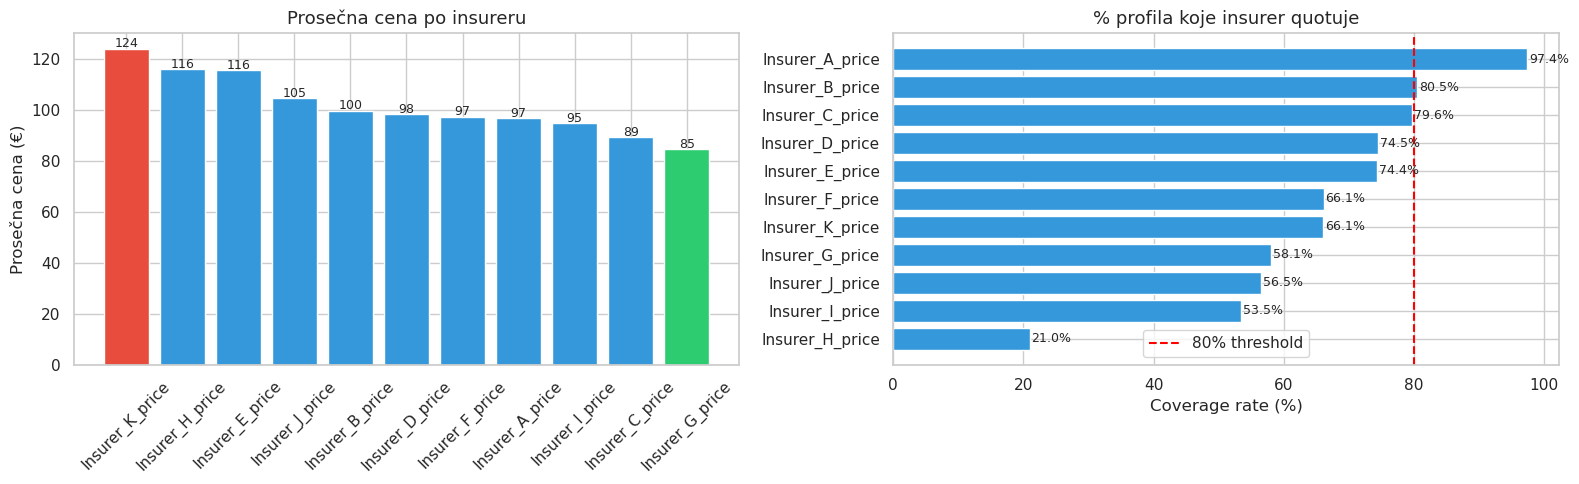

=== KEY NUMBERS ===
Najskuplji:     Insurer_K_price — 124€ prosek
Najjeftiniji:   Insurer_G_price — 85€ prosek
Najselektivniji:Insurer_H_price — quotuje samo 21.0% profila


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Prosečna cena
mean_prices = train_raw[insurer_cols].mean().sort_values(ascending=False)
colors = ['#e74c3c' if i == 0 else '#2ecc71' if i == len(mean_prices)-1 
          else '#3498db' for i in range(len(mean_prices))]
axes[0].bar(mean_prices.index, mean_prices.values, color=colors)
axes[0].set_title('Prosečna cena po insureru', fontsize=13)
axes[0].set_ylabel('Prosečna cena (€)')
axes[0].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(mean_prices.items()):
    axes[0].text(i, val + 0.5, f'{val:.0f}', ha='center', fontsize=9)

# Coverage rate
coverage_rate = (train_raw[insurer_cols].notnull().sum() / len(train_raw) * 100).sort_values()
axes[1].barh(coverage_rate.index, coverage_rate.values, color='#3498db')
axes[1].axvline(x=80, color='red', linestyle='--', label='80% threshold')
axes[1].set_title('% profila koje insurer quotuje', fontsize=13)
axes[1].set_xlabel('Coverage rate (%)')
axes[1].legend()
for i, (idx, val) in enumerate(coverage_rate.items()):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('01_overview.png', dpi=150)
plt.show()

# Printuj key numbers
print("=== KEY NUMBERS ===")
print(f"Najskuplji:     {mean_prices.index[0]} — {mean_prices.iloc[0]:.0f}€ prosek")
print(f"Najjeftiniji:   {mean_prices.index[-1]} — {mean_prices.iloc[-1]:.0f}€ prosek")
print(f"Najselektivniji:{coverage_rate.index[0]} — quotuje samo {coverage_rate.iloc[0]:.1f}% profila")

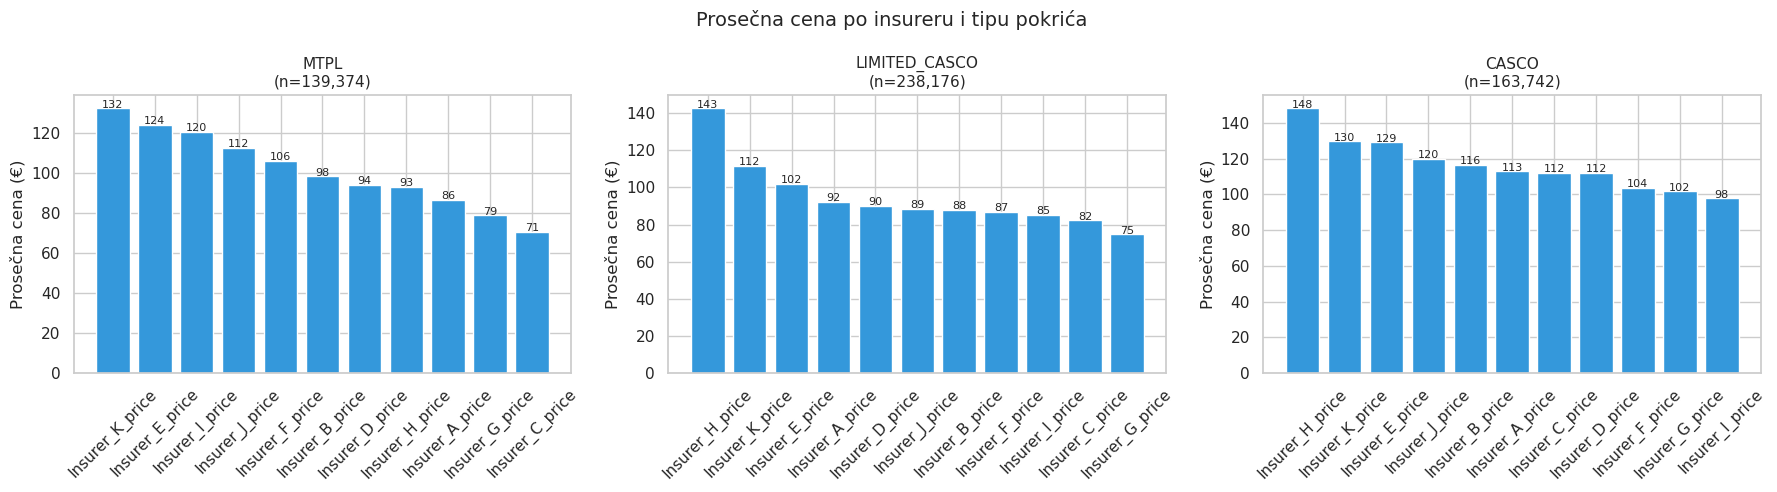

=== DOMINACIJA PO SEGMENTU ===
mtpl            → najjeftiniji: Insurer_C_price (71€) | najskuplji: Insurer_K_price (132€)
limited_casco   → najjeftiniji: Insurer_G_price (75€) | najskuplji: Insurer_H_price (143€)
casco           → najjeftiniji: Insurer_I_price (98€) | najskuplji: Insurer_H_price (148€)


In [13]:
coverage_types = ['mtpl', 'limited_casco', 'casco']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cov in zip(axes, coverage_types):
    subset = train_raw[train_raw['coverage'] == cov]
    means = subset[insurer_cols].mean().sort_values(ascending=False)
    ax.bar(means.index, means.values, color='#3498db')
    ax.set_title(f'{cov.upper()}\n(n={len(subset):,})', fontsize=11)
    ax.set_ylabel('Prosečna cena (€)')
    ax.tick_params(axis='x', rotation=45)
    for i, (idx, val) in enumerate(means.items()):
        ax.text(i, val + 0.3, f'{val:.0f}', ha='center', fontsize=8)

plt.suptitle('Prosečna cena po insureru i tipu pokrića', fontsize=14)
plt.tight_layout()
plt.savefig('02_price_by_coverage.png', dpi=150)
plt.show()

# Ko dominira koji segment?
print("=== DOMINACIJA PO SEGMENTU ===")
for cov in coverage_types:
    subset = train_raw[train_raw['coverage'] == cov]
    means = subset[insurer_cols].mean()
    print(f"{cov:15} → najjeftiniji: {means.idxmin()} ({means.min():.0f}€) | "
          f"najskuplji: {means.idxmax()} ({means.max():.0f}€)")

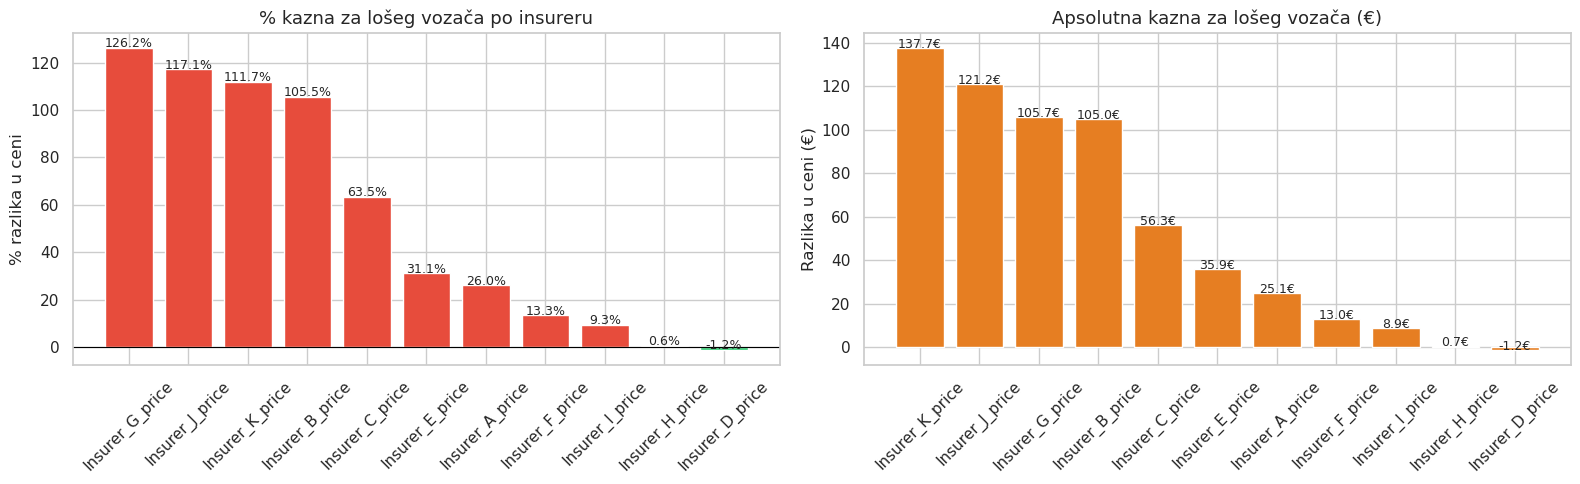

=== BAD DRIVER PENALTY ===
Najviše kažnjava: Insurer_G_price (+126.2%)
Najmanje kažnjava: Insurer_D_price (+-1.2%)

Broj loših vozača u datasetu: 6,092 (1.1%)


In [16]:
train_raw['is_bad_driver'] = (train_raw['claim_free_years'] < 0).astype(int)

good = train_raw[train_raw['is_bad_driver'] == 0][insurer_cols].mean()
bad  = train_raw[train_raw['is_bad_driver'] == 1][insurer_cols].mean()
penalty_pct = ((bad - good) / good * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# % kazna
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in penalty_pct.values]
axes[0].bar(penalty_pct.index, penalty_pct.values, color=colors)
axes[0].set_title('% kazna za lošeg vozača po insureru', fontsize=13)
axes[0].set_ylabel('% razlika u ceni')
axes[0].axhline(y=0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(penalty_pct.items()):
    axes[0].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)

# Apsolutna kazna u €
penalty_abs = (bad - good).sort_values(ascending=False)
axes[1].bar(penalty_abs.index, penalty_abs.values, color='#e67e22')
axes[1].set_title('Apsolutna kazna za lošeg vozača (€)', fontsize=13)
axes[1].set_ylabel('Razlika u ceni (€)')
axes[1].tick_params(axis='x', rotation=45)
for i, (idx, val) in enumerate(penalty_abs.items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}€', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_bad_driver_penalty.png', dpi=150)
plt.show()

print("=== BAD DRIVER PENALTY ===")
print(f"Najviše kažnjava: {penalty_pct.index[0]} (+{penalty_pct.iloc[0]:.1f}%)")
print(f"Najmanje kažnjava: {penalty_pct.index[-1]} (+{penalty_pct.iloc[-1]:.1f}%)")

bad_driver_count = train_raw['is_bad_driver'].sum()
print(f"\nBroj loših vozača u datasetu: {bad_driver_count:,} ({bad_driver_count/len(train_raw)*100:.1f}%)")

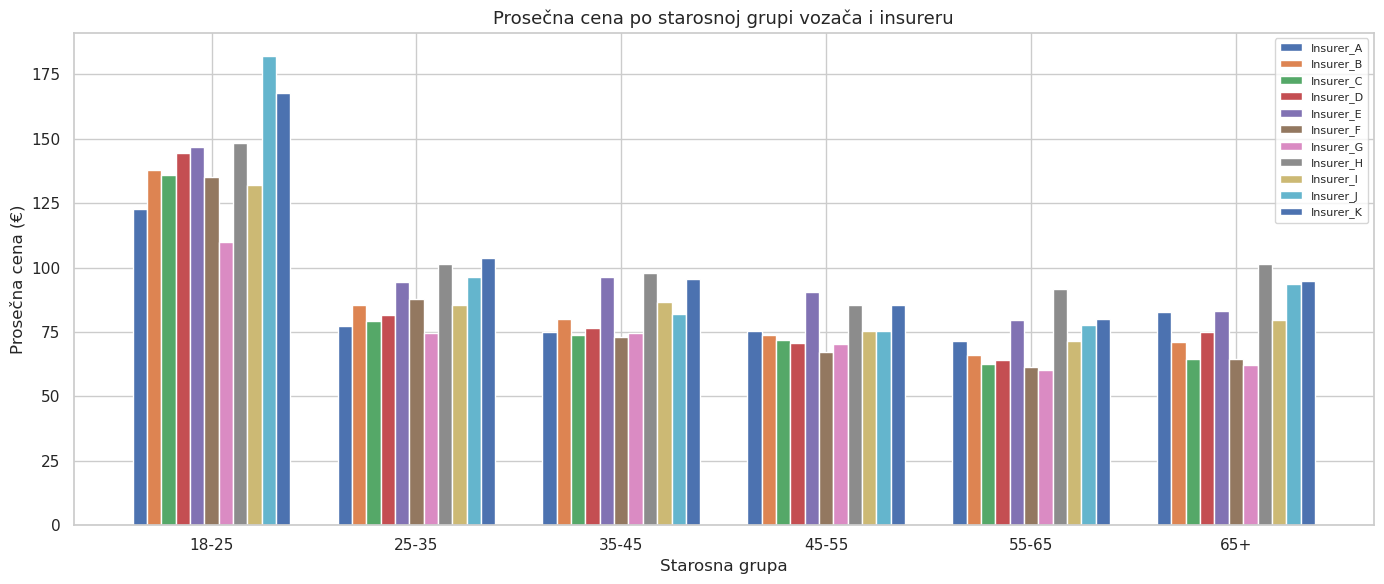

=== CENE ZA MLADE VOZAČE (18-25) ===
Insurer_J_price    181.988133
Insurer_K_price    167.603034
Insurer_H_price    148.525889
Insurer_E_price    146.677279
Insurer_D_price    144.316657
Insurer_B_price    137.743873
Insurer_C_price    135.734969
Insurer_F_price    134.966807
Insurer_I_price    132.196535
Insurer_A_price    122.780372
Insurer_G_price    110.029217
dtype: float64


In [17]:
# Napravi age grupe
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '25-35', '35-45', '45-55', '55-65', '65+']
train_raw['age_group'] = pd.cut(train_raw['driver_age'], bins=bins, labels=labels)

age_prices = train_raw.groupby('age_group', observed=True)[insurer_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(age_prices.index))
width = 0.07

for i, ins in enumerate(insurer_cols):
    ax.bar(x + i * width, age_prices[ins], width, label=ins.replace('_price', ''))

ax.set_title('Prosečna cena po starosnoj grupi vozača i insureru', fontsize=13)
ax.set_xlabel('Starosna grupa')
ax.set_ylabel('Prosečna cena (€)')
ax.set_xticks(x + width * 5)
ax.set_xticklabels(age_prices.index)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('04_price_by_age_group.png', dpi=150)
plt.show()

# Ko najviše naplaćuje mladima?
young = train_raw[train_raw['age_group'] == '18-25'][insurer_cols].mean()
print("=== CENE ZA MLADE VOZAČE (18-25) ===")
print(young.sort_values(ascending=False))

Urban category vrednosti:
postal_code_urban_category
2.0    145192
1.0    142449
3.0     95571
4.0     84800
5.0     72747
Name: count, dtype: int64


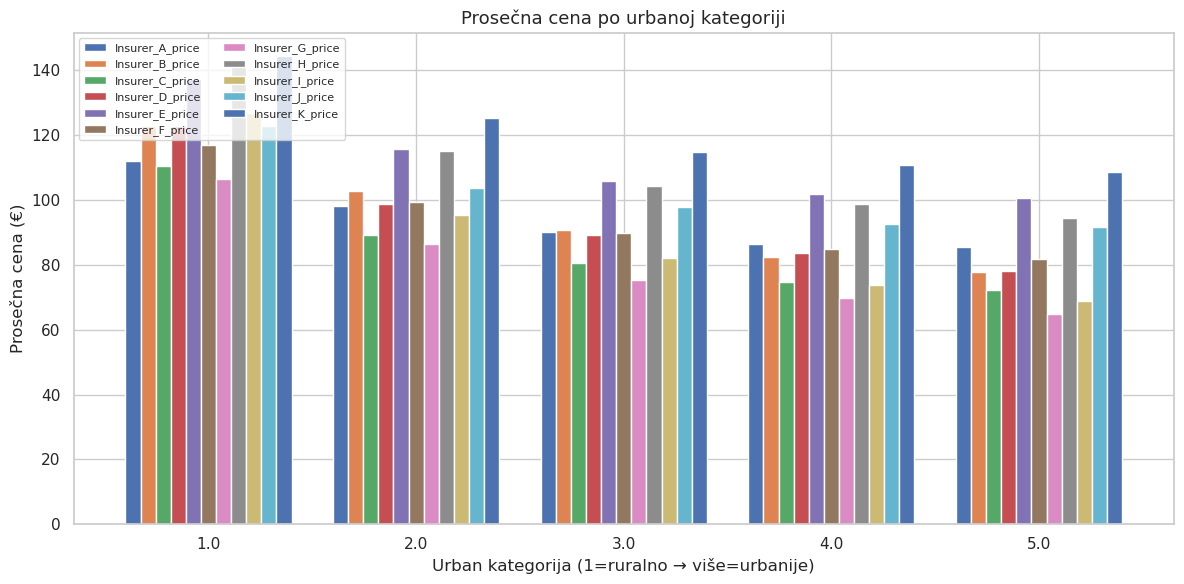

In [18]:
# urban_category — 1=ruralno, higher=urbanije (zavisi od dataseta)
print("Urban category vrednosti:")
print(train_raw['postal_code_urban_category'].value_counts())

urban_prices = train_raw.groupby('postal_code_urban_category')[insurer_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))
urban_prices.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Prosečna cena po urbanoj kategoriji', fontsize=13)
ax.set_xlabel('Urban kategorija (1=ruralno → više=urbanije)')
ax.set_ylabel('Prosečna cena (€)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('05_urban_vs_rural.png', dpi=150)
plt.show()

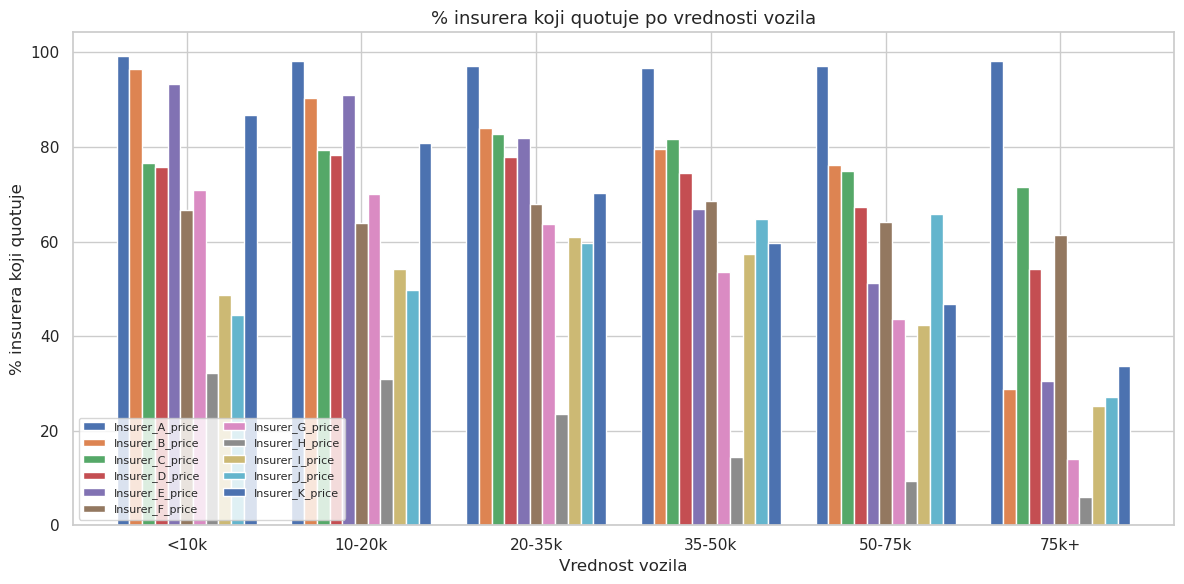

=== PROSEČNA CENA PO VREDNOSTI VOZILA ===
                     Insurer_A_price  Insurer_B_price  Insurer_C_price  \
vehicle_value_group                                                      
<10k                            78.0             99.0             61.0   
10-20k                          78.0             92.0             67.0   
20-35k                          86.0             90.0             82.0   
35-50k                         105.0            104.0            102.0   
50-75k                         127.0            129.0            120.0   
75k+                           153.0            151.0            137.0   

                     Insurer_D_price  Insurer_E_price  Insurer_F_price  \
vehicle_value_group                                                      
<10k                            88.0            106.0             84.0   
10-20k                          88.0            105.0             85.0   
20-35k                          94.0            113.0             90.

In [21]:
# Value grupe vozila
train_raw['vehicle_value_group'] = pd.cut(
    train_raw['vehicle_value_new'],
    bins=[0, 10000, 20000, 35000, 50000, 75000, 999999],
    labels=['<10k', '10-20k', '20-35k', '35-50k', '50-75k', '75k+']
)

# Koliko insurera quotuje svaki value segment?
value_coverage = train_raw.groupby('vehicle_value_group', observed=True)[insurer_cols].apply(
    lambda x: x.notnull().mean() * 100
)

fig, ax = plt.subplots(figsize=(12, 6))
value_coverage.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('% insurera koji quotuje po vrednosti vozila', fontsize=13)
ax.set_xlabel('Vrednost vozila')
ax.set_ylabel('% insurera koji quotuje')
ax.legend(loc='lower left', fontsize=8, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('06_vehicle_value_gap.png', dpi=150)
plt.show()

# Prosečna cena po value grupi
value_prices = train_raw.groupby('vehicle_value_group', observed=True)[insurer_cols].mean()
print("=== PROSEČNA CENA PO VREDNOSTI VOZILA ===")
print(value_prices.round(0))

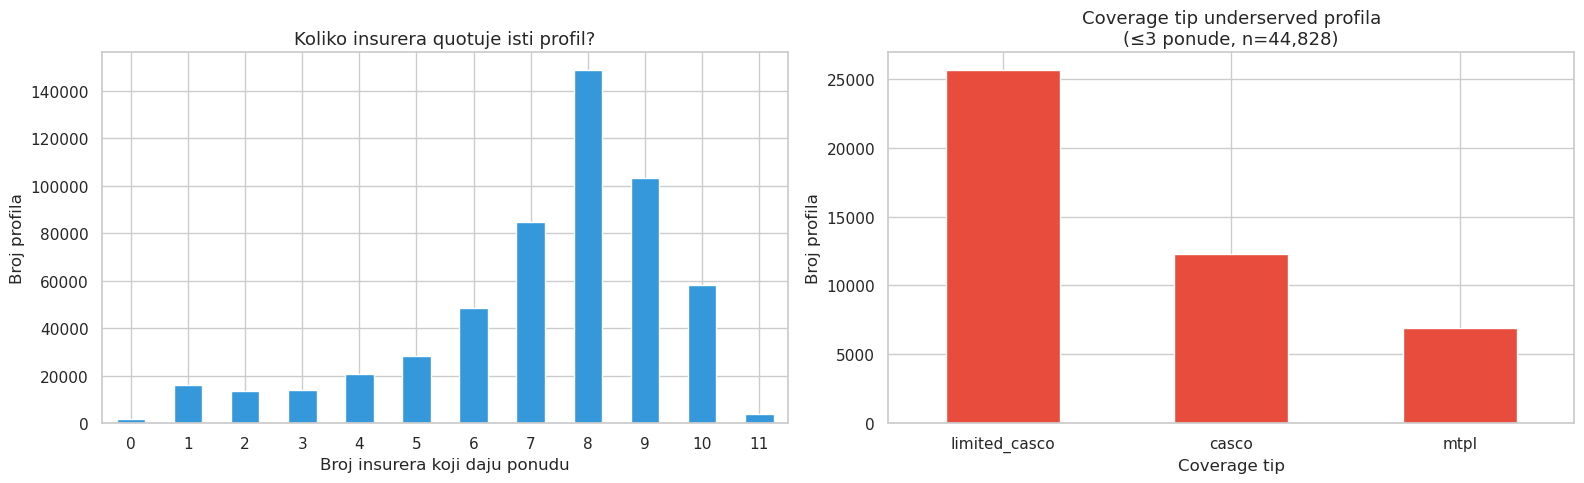

=== MARKET GAP ===
  1 insurer(a) quotuje: 15,860 profila (2.9%)
  2 insurer(a) quotuje: 13,315 profila (2.5%)
  3 insurer(a) quotuje: 13,895 profila (2.6%)
  4 insurer(a) quotuje: 20,712 profila (3.8%)

Underserved (≤3): 44,828 profila (8.3%)

Coverage tip underserved:
coverage
limited_casco    25662
casco            12295
mtpl              6871
Name: count, dtype: int64

Usage tip underserved:
usage
private_use    44828
Name: count, dtype: int64


In [22]:
train_raw['num_quotes'] = train_raw[insurer_cols].notnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribucija broja quotova
train_raw['num_quotes'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Koliko insurera quotuje isti profil?', fontsize=13)
axes[0].set_xlabel('Broj insurera koji daju ponudu')
axes[0].set_ylabel('Broj profila')
axes[0].tick_params(axis='x', rotation=0)

# Coverage type kod underserved profila
underserved = train_raw[train_raw['num_quotes'] <= 3]
underserved['coverage'].value_counts().plot(
    kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title(f'Coverage tip underserved profila\n(≤3 ponude, n={len(underserved):,})',
                  fontsize=13)
axes[1].set_xlabel('Coverage tip')
axes[1].set_ylabel('Broj profila')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('07_market_gap.png', dpi=150)
plt.show()

print("=== MARKET GAP ===")
for n in range(1, 5):
    count = (train_raw['num_quotes'] == n).sum()
    print(f"  {n} insurer(a) quotuje: {count:,} profila ({count/len(train_raw)*100:.1f}%)")

print(f"\nUnderserved (≤3): {len(underserved):,} profila ({len(underserved)/len(train_raw)*100:.1f}%)")
print("\nCoverage tip underserved:")
print(underserved['coverage'].value_counts())
print("\nUsage tip underserved:")
print(underserved['usage'].value_counts().head())

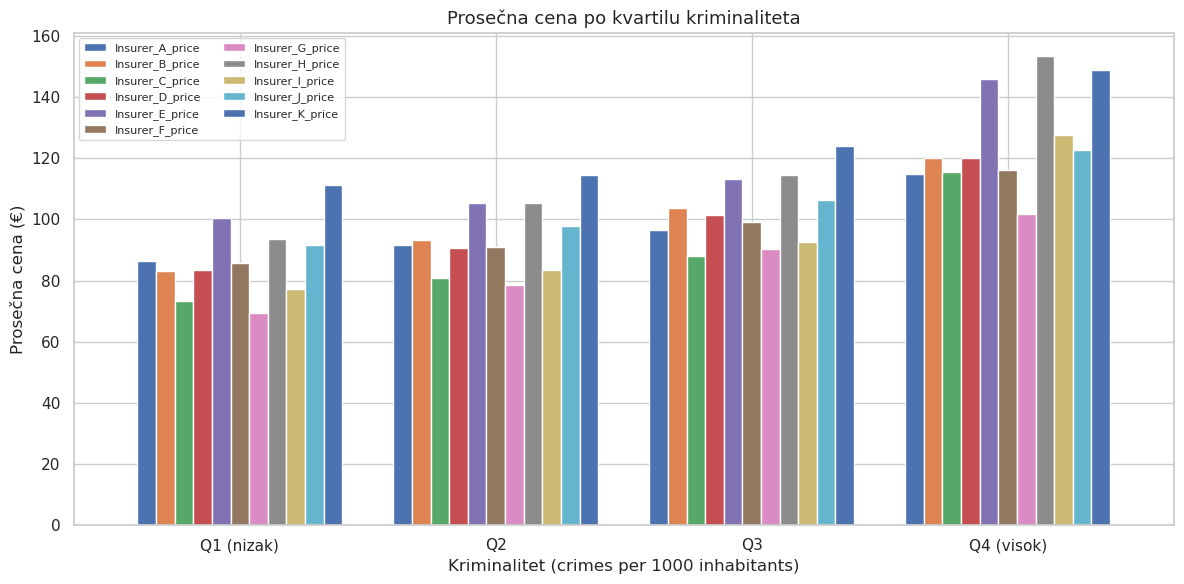

In [25]:
# Ćelija 9 — Kriminal i cena (crime rate)
train_raw['municipality_crimes_per_1000'] = pd.to_numeric(
    train_raw['municipality_crimes_per_1000'], errors='coerce')

train_raw['crime_quartile'] = pd.qcut(
    train_raw['municipality_crimes_per_1000'],
    q=4,
    labels=['Q1 (nizak)', 'Q2', 'Q3', 'Q4 (visok)'],
    duplicates='drop'
)

crime_prices = train_raw.groupby('crime_quartile', observed=True)[insurer_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))
crime_prices.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Prosečna cena po kvartilu kriminaliteta', fontsize=13)
ax.set_xlabel('Kriminalitet (crimes per 1000 inhabitants)')
ax.set_ylabel('Prosečna cena (€)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('08_crime_vs_price.png', dpi=150)
plt.show()

In [26]:
print("=" * 60)
print("FINAL INSIGHTS SUMMARY — za prezentaciju")
print("=" * 60)

mean_prices = train_raw[insurer_cols].mean().sort_values(ascending=False)
coverage_rate = (train_raw[insurer_cols].notnull().sum() / len(train_raw) * 100)
underserved = train_raw[train_raw['num_quotes'] <= 3]

print(f"""
1. PRICING SPREAD
   Najskuplji:   {mean_prices.index[0]} ({mean_prices.iloc[0]:.0f}€ prosek)
   Najjeftiniji: {mean_prices.index[-1]} ({mean_prices.iloc[-1]:.0f}€ prosek)
   Razlika:      {(mean_prices.iloc[0]/mean_prices.iloc[-1]-1)*100:.0f}% skuplje

2. SELEKTIVNOST
   {coverage_rate.idxmin()} quotuje samo {coverage_rate.min():.1f}% profila
   {coverage_rate.idxmax()} quotuje {coverage_rate.max():.1f}% profila

3. MARKET GAP
   {len(underserved):,} profila ({len(underserved)/len(train_raw)*100:.1f}%) dobija ≤3 ponude
   → Ovo je segment gde novi insurer može da uđe

4. BAD DRIVER PENALTY
   Najviše kažnjava: {penalty_pct.index[0]} (+{penalty_pct.iloc[0]:.1f}%)
   Najmanje kažnjava: {penalty_pct.index[-1]} (+{penalty_pct.iloc[-1]:.1f}%)

5. PREPORUKA ZA NOVOG INSURERA
   → Targetirati underserved segmente (≤3 ponude)
   → Biti konkurentan u casco segmentu gde {mean_prices.index[0]} overpriceuje
   → Biti tolerantniji prema lošim vozačima nego {penalty_pct.index[0]}
   → Fokusirati se na vozila srednje vrednosti (20-35k) gde je konkurencija slabija
""")

FINAL INSIGHTS SUMMARY — za prezentaciju

1. PRICING SPREAD
   Najskuplji:   Insurer_K_price (124€ prosek)
   Najjeftiniji: Insurer_G_price (85€ prosek)
   Razlika:      47% skuplje

2. SELEKTIVNOST
   Insurer_H_price quotuje samo 21.0% profila
   Insurer_A_price quotuje 97.4% profila

3. MARKET GAP
   44,828 profila (8.3%) dobija ≤3 ponude
   → Ovo je segment gde novi insurer može da uđe

4. BAD DRIVER PENALTY
   Najviše kažnjava: Insurer_G_price (+126.2%)
   Najmanje kažnjava: Insurer_D_price (+-1.2%)

5. PREPORUKA ZA NOVOG INSURERA
   → Targetirati underserved segmente (≤3 ponude)
   → Biti konkurentan u casco segmentu gde Insurer_K_price overpriceuje
   → Biti tolerantniji prema lošim vozačima nego Insurer_G_price
   → Fokusirati se na vozila srednje vrednosti (20-35k) gde je konkurencija slabija

